# SECTION 1
# Imports + Dataset Loading+Data Cleaning

# **Importing Libraries**

In [1]:
# Importing required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# **Loading data**

In [3]:
# Connecting to the google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Testing the shape of the single file in the IMS dataset
data=np.loadtxt('/content/drive/MyDrive/MASTER_IN_AI_ML/Walsh/Capstone/IMS_folder/1st_test/2003.10.22.12.06.24')
print(data.shape)

(20480, 8)


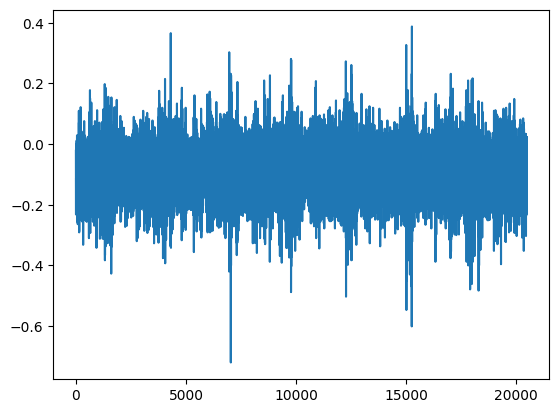

In [4]:
# Observing the distrubution for the signal at a point of time
plt.plot(data[:,0])
plt.show()

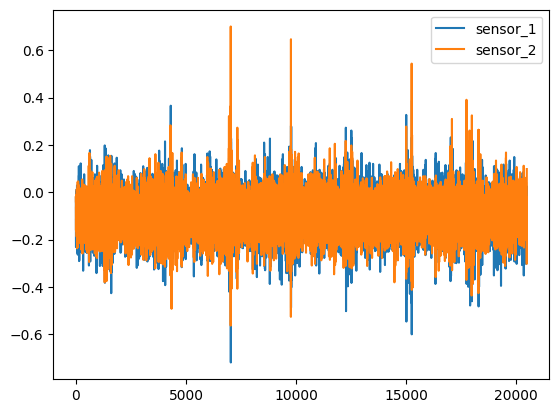

In [5]:
# Comparing two sensors
plt.plot(data[:,0],label='sensor_1')
plt.plot(data[:,1],label='sensor_2')
plt.legend()

In [6]:
print(data[:5])

[[-0.022 -0.039 -0.183 -0.054 -0.105 -0.134 -0.129 -0.142]
 [-0.105 -0.017 -0.164 -0.183 -0.049  0.029 -0.115 -0.122]
 [-0.183 -0.098 -0.195 -0.125 -0.005 -0.007 -0.171 -0.071]
 [-0.178 -0.161 -0.159 -0.178 -0.1   -0.115 -0.112 -0.078]
 [-0.208 -0.129 -0.261 -0.098 -0.151 -0.205 -0.063 -0.066]]


In [7]:
print(data[:,0])


[-0.022 -0.105 -0.183 ... -0.193 -0.115 -0.042]


In [8]:
signal = data

# **Data relocation and Feature Extraction**

In [9]:
# Locating data to another location for better storage
!cp -r "/content/drive/MyDrive/MASTER_IN_AI_ML/Walsh/Capstone/IMS_folder" /content/

In [10]:
print(os.listdir("/content"))

['.config', 'drive', 'IMS_folder', 'sample_data']


In [11]:
print(os.listdir("/content/IMS_folder"))

['2nd_test', '3rd_test', '1st_test']


In [12]:
import os
import numpy as np
from scipy.stats import skew, kurtosis

base_folder = "/content/IMS_folder"
final_dataset = []

#  Lock number of channels (VERY IMPORTANT)
MAX_CHANNELS = 4   # adjust based on dataset (IMS usually 4 or 8)

#  Safe statistical functions
def safe_stat(x, func):
    try:
        val = func(x)
        if np.isnan(val) or np.isinf(val):
            return 0
        return val
    except:
        return 0

#  Safe FFT-based features
def safe_fft_features(col, fs):
    if len(col) < 10 or np.all(col == 0):
        return 0, 0, 0

    try:
        fft_vals = np.fft.fft(col)
        fft_mag = np.abs(fft_vals[:len(col)//2])

        freqs = np.fft.fftfreq(len(col), d=1/fs)
        freqs = freqs[:len(col)//2]

        power_spectrum = fft_mag**2

        energy = np.sum(power_spectrum)

        prob = power_spectrum / (energy + 1e-10)
        entropy = -np.sum(prob * np.log2(prob + 1e-10))

        dominant_idx = np.argmax(fft_mag)
        dominant_freq = freqs[dominant_idx]

        # safety cleanup
        if np.isnan(entropy) or np.isinf(entropy):
            entropy = 0

        return energy, entropy, dominant_freq

    except:
        return 0, 0, 0


def extract_features(signal, fs=20000):
    feature = {}

    #  Ensure 2D
    if signal.ndim == 1:
        signal = signal.reshape(-1, 1)

    num_channels = min(signal.shape[1], MAX_CHANNELS)

    #  Process only consistent number of channels
    for i in range(MAX_CHANNELS):

        if i < num_channels:
            col = signal[:, i]

            # -------- Time Domain --------
            rms = np.sqrt(np.mean(col**2)) if len(col) > 0 else 0
            variance = np.var(col) if len(col) > 0 else 0
            skewness = safe_stat(col, skew)
            kurt_val = safe_stat(col, kurtosis)
            peak = np.max(np.abs(col)) if len(col) > 0 else 0

            crest = peak / (rms + 1e-10)

            # -------- Frequency Domain --------
            energy, entropy, dom_freq = safe_fft_features(col, fs)

        else:
            #  Fill missing channels with zeros (CRITICAL FIX)
            rms = variance = skewness = kurt_val = crest = 0
            energy = entropy = dom_freq = 0

        #  Always create same columns
        feature[f"rms_{i}"] = rms
        feature[f"variance_{i}"] = variance
        feature[f"skewness_{i}"] = skewness
        feature[f"kurtosis_{i}"] = kurt_val
        feature[f"crest_factor_{i}"] = crest
        feature[f"fft_energy_{i}"] = energy
        feature[f"spectral_entropy_{i}"] = entropy
        feature[f"dominant_freq_{i}"] = dom_freq

    return feature


#  LOOP

for subfolder in sorted(os.listdir(base_folder)):
    subfolder_path = os.path.join(base_folder, subfolder)

    if os.path.isdir(subfolder_path):
        for file in sorted(os.listdir(subfolder_path)):

            if not file.startswith('.'):
                file_path = os.path.join(subfolder_path, file)

                try:
                    data = np.loadtxt(file_path)

                    #  Skip corrupted or empty files
                    if data.size == 0:
                        print(f"Skipping empty file: {file}")
                        continue

                except Exception as e:
                    print(f"Skipping {file}: {e}")
                    continue

                features = extract_features(data)

                features["file_name"] = file
                features["source"] = subfolder

                final_dataset.append(features)



In [13]:
df_ims = pd.DataFrame(final_dataset)
print(df_ims.shape)

(9463, 34)


In [14]:
df_ims = pd.DataFrame(final_dataset)
df_ims.to_csv("/content/drive/MyDrive/MASTER_IN_AI_ML/Walsh/Capstone/ims_features.csv", index=False)

In [15]:
# Checking for the missing values
df_ims.isnull().sum().value_counts()

,count
0,34


In [16]:
df_ims.isnull().sum()

,0
rms_0,0
variance_0,0
skewness_0,0
kurtosis_0,0
crest_factor_0,0
fft_energy_0,0
spectral_entropy_0,0
dominant_freq_0,0
rms_1,0
variance_1,0


In [17]:
#  Final safety cleanup
df_ims.replace([np.inf, -np.inf], 0, inplace=True)
df_ims.fillna(0, inplace=True)

In [18]:
df_ims.shape

(9463, 34)

In [ ]:
df_ims.isnull().sum().value_counts()

In [19]:
print(df_ims.head(5))

      rms_0  variance_0  skewness_0  kurtosis_0  crest_factor_0  fft_energy_0  \
0  0.124614    0.006581   -0.029993    1.069163        5.777850  5.133067e+06   
1  0.123811    0.006323   -0.070075    1.161552        5.282236  5.103566e+06   
2  0.125246    0.006435   -0.041646    0.986286        4.974196  5.229994e+06   
3  0.125197    0.006533    0.005162    1.034294        4.776455  5.204334e+06   
4  0.125618    0.006730   -0.060196    1.110164        4.959475  5.207247e+06   

   spectral_entropy_0  dominant_freq_0     rms_1  variance_1  ...     rms_3  \
0            3.420992              0.0  0.117493    0.004991  ...  0.121642   
1            3.292894              0.0  0.116833    0.004834  ...  0.122182   
2            3.240956              0.0  0.118384    0.004825  ...  0.123572   
3            3.403186              0.0  0.119005    0.005079  ...  0.122750   
4            3.508519              0.0  0.119688    0.005206  ...  0.121866   

   variance_3  skewness_3  kurtosis_3 

In [20]:
df_ims.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9463 entries, 0 to 9462
Data columns (total 34 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   rms_0               9463 non-null   float64
 1   variance_0          9463 non-null   float64
 2   skewness_0          9463 non-null   float64
 3   kurtosis_0          9463 non-null   float64
 4   crest_factor_0      9463 non-null   float64
 5   fft_energy_0        9463 non-null   float64
 6   spectral_entropy_0  9463 non-null   float64
 7   dominant_freq_0     9463 non-null   float64
 8   rms_1               9463 non-null   float64
 9   variance_1          9463 non-null   float64
 10  skewness_1          9463 non-null   float64
 11  kurtosis_1          9463 non-null   float64
 12  crest_factor_1      9463 non-null   float64
 13  fft_energy_1        9463 non-null   float64
 14  spectral_entropy_1  9463 non-null   float64
 15  dominant_freq_1     9463 non-null   float64
 16  rms_2 

- There are no missng values here

In [21]:
pd.set_option('display.float_format', '{:.6f}'.format)
df_ims.describe().T

,count,mean,std,min,25%,50%,75%,max
rms_0,9463.000000,0.095264,0.037959,0.001533,0.072263,0.075311,0.125482,0.725001
variance_0,9463.000000,0.007443,0.010345,0.000001,0.005217,0.005668,0.008705,0.525620
skewness_0,9463.000000,0.002225,0.051488,-0.766067,-0.023187,0.006034,0.032737,0.579698
kurtosis_0,9463.000000,0.601971,0.433289,-1.609774,0.352957,0.480076,0.788374,14.110009
crest_factor_0,9463.000000,5.245539,0.742263,2.377543,4.758064,5.118587,5.583891,10.256522
fft_energy_0,9463.000000,2849934.720401,3414612.196905,775.825700,1096362.035474,1190445.068414,3891095.215773,110233128.053052
spectral_entropy_0,9463.000000,9.000757,2.915263,1.749463,9.743582,10.510463,10.775631,11.554790
dominant_freq_0,9463.000000,814.102355,612.548660,0.000000,985.351562,985.351562,986.328125,4849.609375
rms_1,9463.000000,0.097673,0.028993,0.001239,0.077843,0.081170,0.114048,0.272873
variance_1,9463.000000,0.007310,0.002978,0.000001,0.006034,0.006529,0.008094,0.074457


# Data Description

- The dataset contains vibration measurements from 4 sensors/bearings.
Sensor-specific features are identified using suffixes:


      _0 → Sensor 1

      _1 → Sensor 2

      _2 → Sensor 3

      _3 → Sensor 4


Extracted Features-

- Time-Domain Features - RMS, Variance, Skewness, Kurtosis, Crest Factor

- Frequency-Domain Features -  FFT Energy, Spectral Entropy, Dominant Frequency


- RMS(Root mean square) - It indicates overall energy/ intensity of vibration. It is often the first indicator of degradation.

- Variance - It indicates spread of signal and tracks instability in vibration.

- Skewness - It indicates asymmetry of signal and helps detect imbalance or directional faults.

- Kurtosis - It indicates presence of spikes/impulsive shocks, It is very sensitive to rare but extreme events.

- Crest Factor - It is the ratio of peak value to RMS value, great for detecting impact type faults.

- FFT Energy - Total energy in the frequency domain.

- Spectral Entropy - How spread out the frequencies are.

- Dominant Frequency - Frequency with highest amplitude


- rms_0 has a mean of 0.095 and standard deviation of 0.037, indicating moderate variability in vibration amplitude. The minimum value is 0.001533, while the maximum value reaches 0.725001, indicating the presence of significant spikes or abnormal vibration events. Such sudden increases in RMS may indicate developing bearing degradation or transient fault behavior.

- rms_2 has the highest maximum value (0.758765) among all sensors, suggesting Sensor 3 may experience stronger abnormal vibration activity or degradation events. rms_3 has the lowest mean RMS (0.075), indicating relatively stable vibration behavior compared to other sensors.

- variance_2 has the highest maximum value (0.573006) among all sensors, suggesting Sensor 3 may experience stronger abnormal vibration activity or degradation events,variance_0 also has a high max value (0.525620).

- kurtosis_0 and kurtosis_2 exhibit extremely high maximum values (14.11 and 16.74), indicating impulsive shock-like events commonly associated with bearing defects.
crest_factor_2 reaches a maximum of 12.75, suggesting strong transient peaks and possible localized bearing faults.

- fft_energy_0 and fft_energy_2 show extremely high standard deviations and maximum values, indicating large fluctuations in frequency-domain energy.
Increasing FFT energy may correspond to worsening bearing health and increased vibration intensity.

- Higher spectral entropy values indicate increased frequency complexity and disorder in the vibration signal.
Sensors 2 and 3 show relatively high entropy variation, which may reflect evolving fault dynamics.

- Dominant frequencies for most sensors are concentrated near 985 Hz, indicating repetitive vibration behavior around a common operating frequency.
However, wide standard deviations and maximum frequencies above 4 kHz suggest intermittent high-frequency fault components.

- Standard deviation exceeding the mean in several features indicates substantial dispersion and potential outlier presence.
This behavior is characteristic of non-stationary degradation signals in rotating machinery.













In [22]:
df_ims.source.unique()

array(['1st_test', '2nd_test', '3rd_test'], dtype=object)

# **Exploratory Data Analysis**

###  Signal_distribution

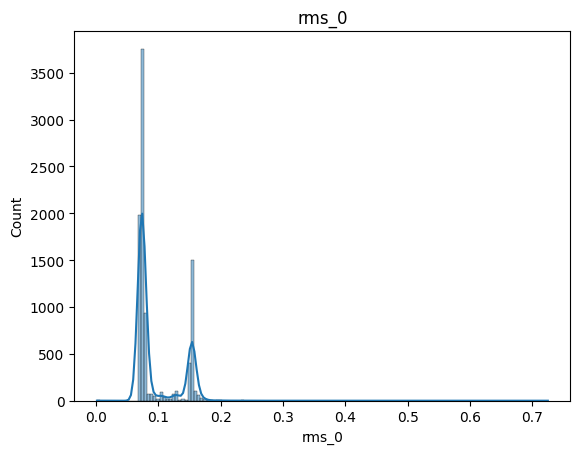

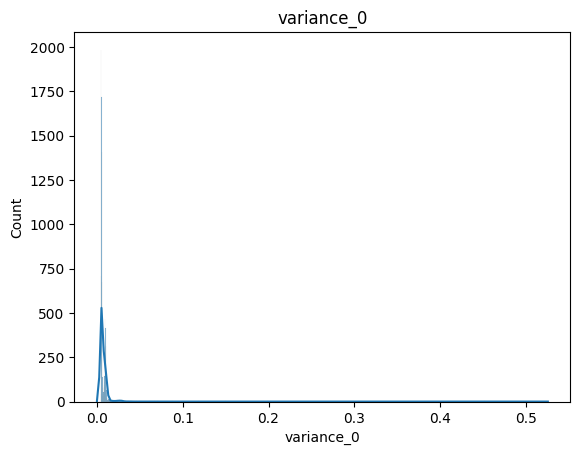

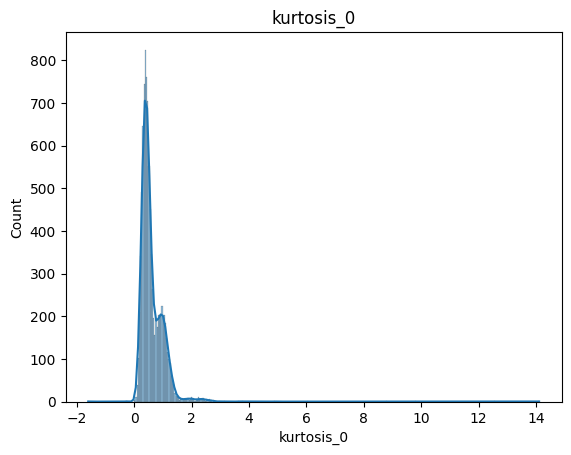

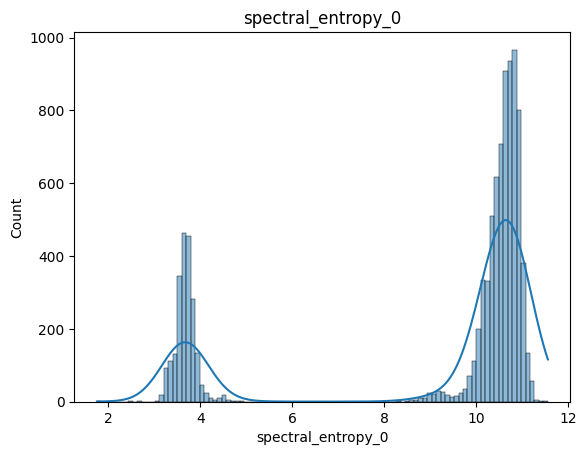

In [23]:
cols = ["rms_0", "variance_0", "kurtosis_0", "spectral_entropy_0"]

for col in cols:
    sns.histplot(df_ims[col], kde=True)
    plt.title(col)
    plt.show()

- rms_0 seems to have high degradation pattern at 0.07-0.08 and 1.4-1.5.
- Increasing RMS values indicate rising vibration energy, which is commonly associated with bearing wear and fault progression in rotating machinery.
- variance_0 seems to have highly concentrated near zero, extreme right skew, few very large values.
- The presence of high-variance outliers indicates unstable vibration behavior and supports the existence of degradation-related anomalies.
- Most values between 0-2, value is given till 14, the sudden spike in the vibration indicates the impulsive vibration behavior typically associated with localized bearing defects such as inner race or outer race faults.
- For spectral_entropy one cluster around ~3-4, another around ~10-11, The bimodal nature of spectral entropy suggests the existence of multiple operational health states within the dataset, potentially representing healthy and degraded bearing conditions.

### Correlation_map

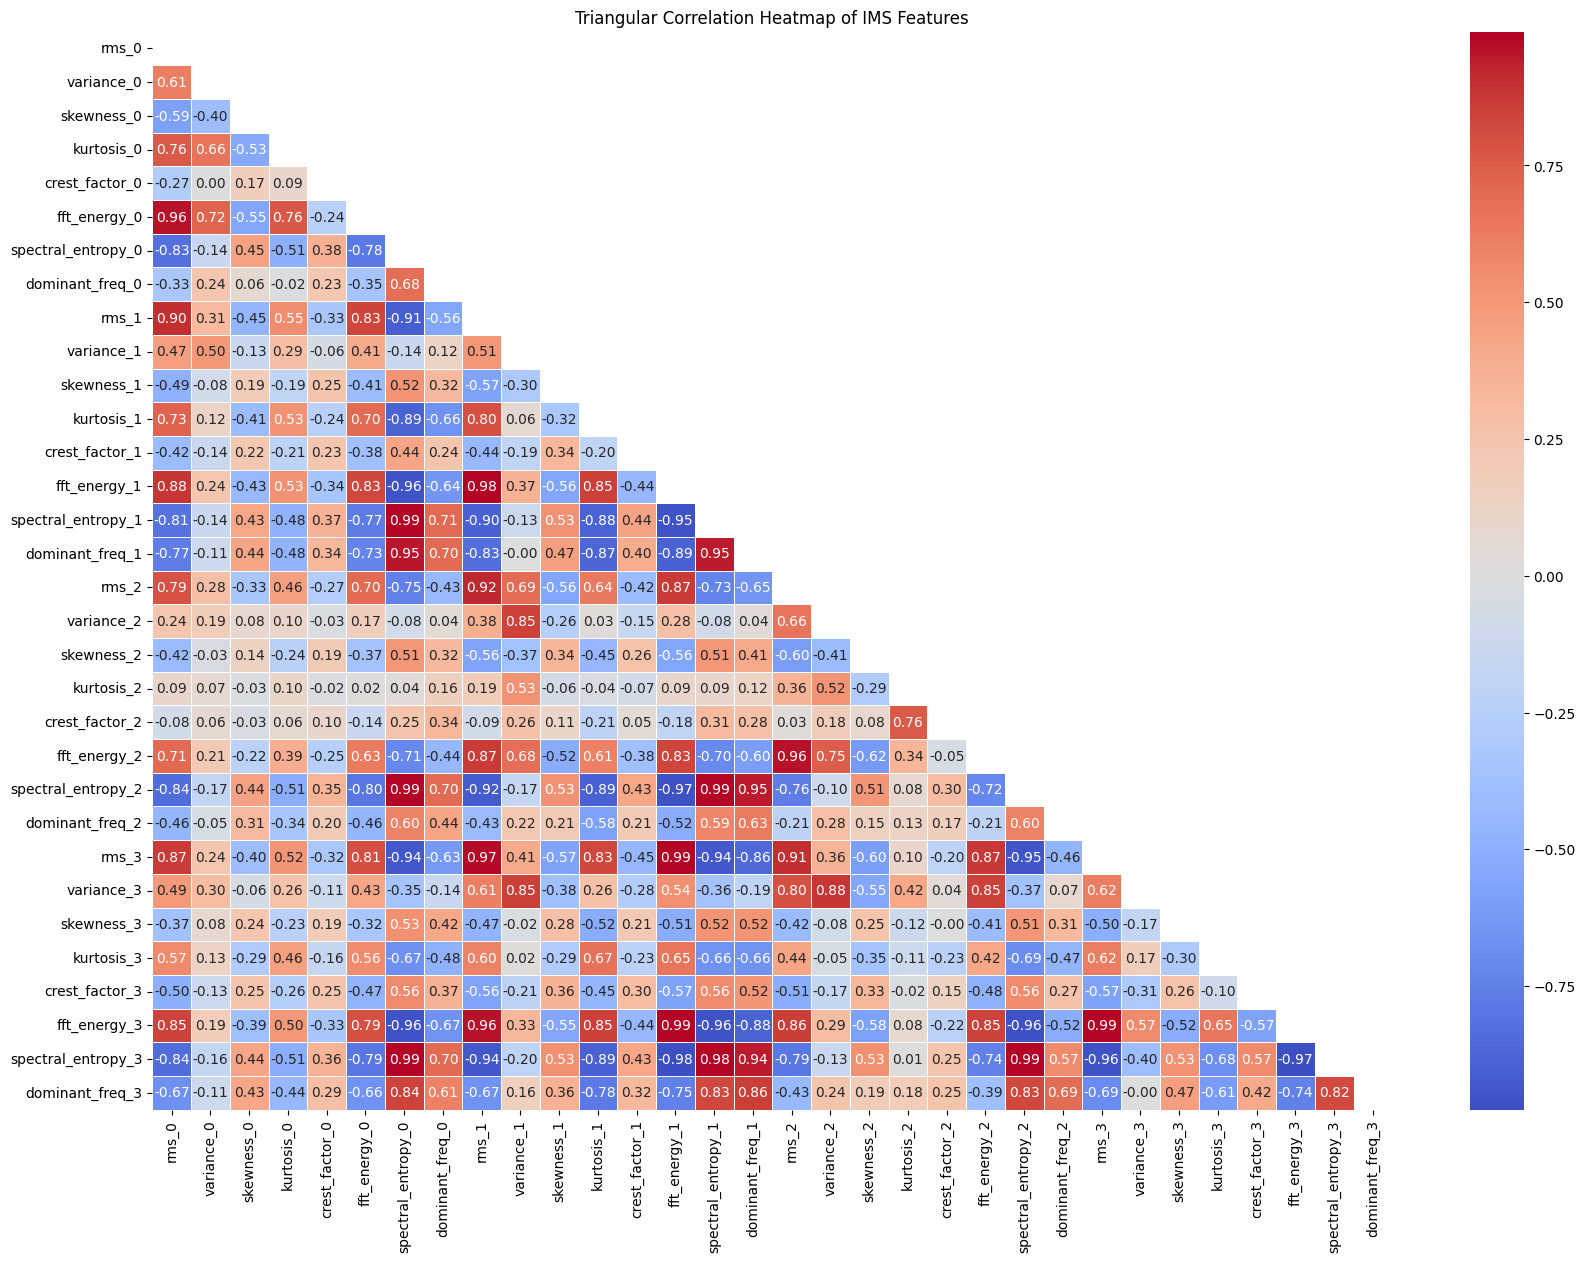

In [24]:
# Correlation matrix
corr_matrix = df_ims.drop(columns=["file_name", "source"]).corr()

# Upper triangle mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot
plt.figure(figsize=(20,14))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Triangular Correlation Heatmap of IMS Features")
plt.show()

In [25]:
threshold = 0.85

corr_pairs = []

corr_matrix = df_ims.drop(columns=["file_name", "source"]).corr()

for i in range(len(corr_matrix.columns)):
    for j in range(i):

        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) > threshold:

            corr_pairs.append({
                "Feature 1": corr_matrix.columns[i],
                "Feature 2": corr_matrix.columns[j],
                "Correlation": round(corr_value, 2)
            })

# Convert to DataFrame
corr_df = pd.DataFrame(corr_pairs)

# Sort by absolute correlation
corr_df["Abs Corr"] = corr_df["Correlation"].abs()

corr_df = corr_df.sort_values(
    by="Abs Corr",
    ascending=False
).drop(columns=["Abs Corr"])

corr_df.head(20)

,Feature 1,Feature 2,Correlation
20,spectral_entropy_2,spectral_entropy_0,0.990000
8,spectral_entropy_1,spectral_entropy_0,0.990000
46,spectral_entropy_3,spectral_entropy_0,0.990000
52,spectral_entropy_3,spectral_entropy_2,0.990000
40,fft_energy_3,fft_energy_1,0.990000
45,fft_energy_3,rms_3,0.990000
29,rms_3,fft_energy_1,0.990000
24,spectral_entropy_2,spectral_entropy_1,0.990000
49,spectral_entropy_3,fft_energy_1,-0.980000
50,spectral_entropy_3,spectral_entropy_1,0.980000


- Observation table above indicates the highest correlation table.



### Degradation_trend

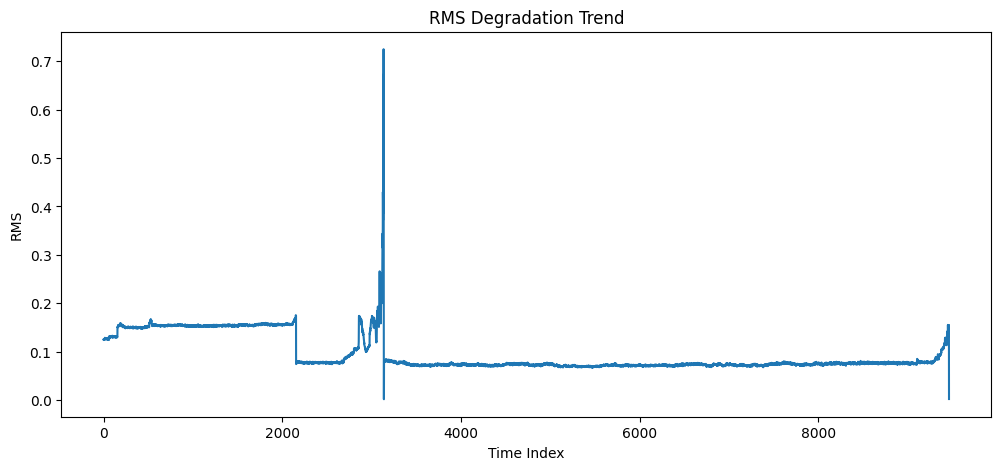

In [26]:
# RMS Degradation Trend
df_ims["time_index"] = range(len(df_ims))

plt.figure(figsize=(12,5))
plt.plot(df_ims["time_index"], df_ims["rms_0"])
plt.title("RMS Degradation Trend")
plt.xlabel("Time Index")
plt.ylabel("RMS")
plt.show()

- The increasing irregularity and extreme spike observed in the rms trend suggest the development of a fault/degradation pattern in the bearing over time.

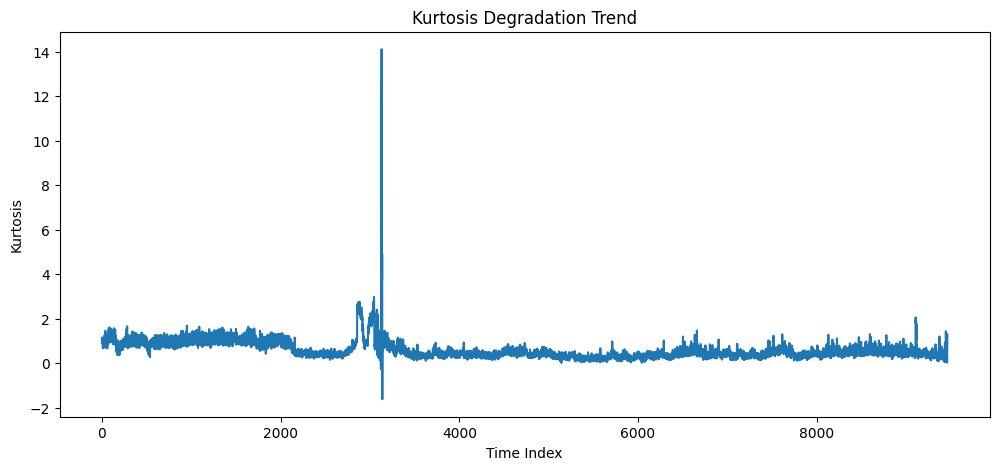

In [27]:
# Kurtosis Degradation Trend
df_ims["time_index"] = range(len(df_ims))

plt.figure(figsize=(12,5))
plt.plot(df_ims["time_index"], df_ims["kurtosis_0"])
plt.title("Kurtosis Degradation Trend")
plt.xlabel("Time Index")
plt.ylabel("Kurtosis")
plt.show()

- Kurtosis degradation trends shows irregularity and high vibrational trend suggest the development of a fault/degradation pattern in the bearing over time.

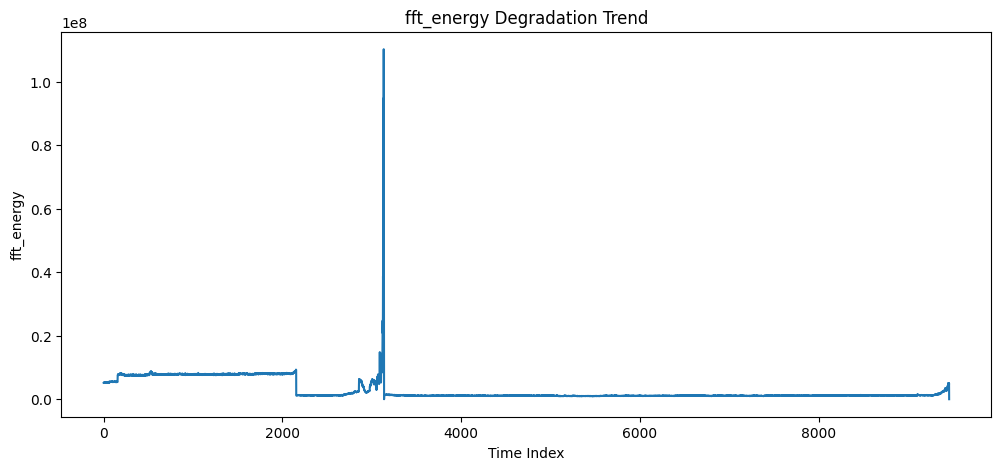

In [28]:
# fft_energy Degradation Trend
df_ims["time_index"] = range(len(df_ims))

plt.figure(figsize=(12,5))
plt.plot(df_ims["time_index"], df_ims["fft_energy_0"])
plt.title("fft_energy Degradation Trend")
plt.xlabel("Time Index")
plt.ylabel("fft_energy")
plt.show()

- The increasing irregularity and extreme spike observed in the FFT energy trend suggest the development of a fault/degradation pattern in the bearing over time.

### RMS_Distribution

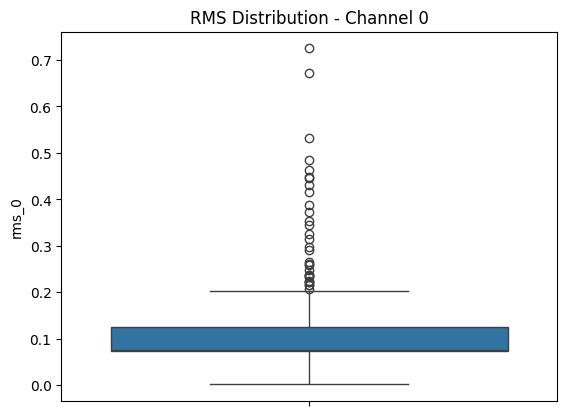

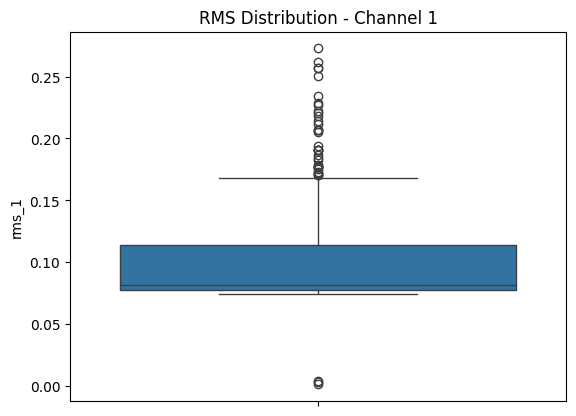

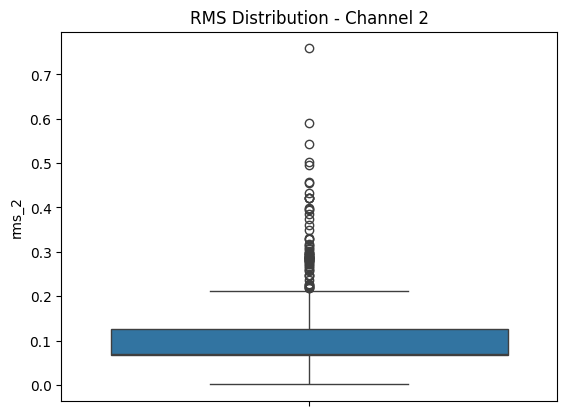

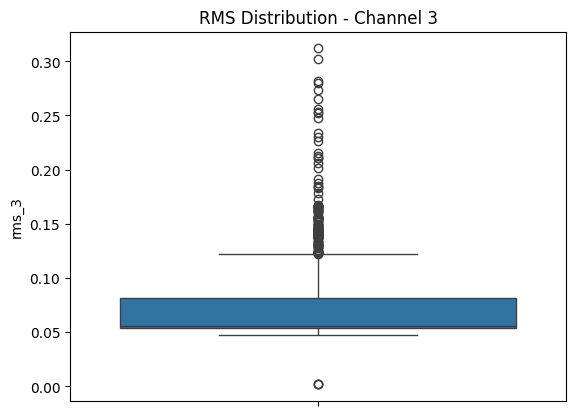

In [29]:
for i in range(4):
    sns.boxplot(y=df_ims[f"rms_{i}"])
    plt.title(f"RMS Distribution - Channel {i}")
    plt.show()

- As it is quite visible that there are so many outliers present in the rms_distribution which is right skewed(positively skewed).

# **Cross_Domain_IMS_dataset_preparation**

In [30]:
# CROSS-DOMAIN IMS PIPELINE

base_folder = "/content/IMS_folder"

final_dataset_crossdomain = []

# LOCK NUMBER OF CHANNELS
MAX_CHANNELS = 4

# SAFE STATISTICAL FUNCTIONS
def safe_stat(x, func):

    try:
        val = func(x)

        if np.isnan(val) or np.isinf(val):
            return 0

        return val

    except:
        return 0


# SAFE FFT FEATURES

def safe_fft_features(col, fs):

    if len(col) < 10 or np.all(col == 0):
        return 0, 0, 0

    try:

        fft_vals = np.fft.fft(col)

        fft_mag = np.abs(
            fft_vals[:len(col)//2]
        )

        freqs = np.fft.fftfreq(
            len(col),
            d=1/fs
        )

        freqs = freqs[:len(col)//2]

        power_spectrum = fft_mag**2

        # FFT Energy
        energy = np.sum(power_spectrum)

        # Spectral Entropy
        prob = power_spectrum / (energy + 1e-10)

        entropy = -np.sum(
            prob * np.log2(prob + 1e-10)
        )

        # Dominant Frequency
        dominant_idx = np.argmax(fft_mag)

        dominant_freq = freqs[dominant_idx]

        # Safety cleanup
        if np.isnan(entropy) or np.isinf(entropy):
            entropy = 0

        return energy, entropy, dominant_freq

    except:
        return 0, 0, 0


# CROSS-DOMAIN FEATURE EXTRACTION

def extract_features_crossdomain(signal, fs=20000):

    feature = {}

    # Ensure 2D

    if signal.ndim == 1:
        signal = signal.reshape(-1, 1)

    # Process consistent number of channels


    num_channels = min(signal.shape[1],MAX_CHANNELS)

    # Store channel-wise values

    rms_list = []
    variance_list = []
    skewness_list = []
    kurtosis_list = []
    crest_list = []

    energy_list = []
    entropy_list = []
    domfreq_list = []

    # LOOP THROUGH CHANNELS


    for i in range(num_channels):

        col = signal[:, i]

        # Skip empty channels
        if len(col) == 0:
            continue


        # TIME DOMAIN FEATURES

        rms = np.sqrt(np.mean(col**2))

        variance = np.var(col)

        skewness = safe_stat(
            col,
            skew
        )

        kurt_val = safe_stat(
            col,
            kurtosis
        )

        peak = np.max(np.abs(col))

        crest = peak / (rms + 1e-10)

        # FREQUENCY DOMAIN FEATURES

        energy, entropy, dom_freq = (
            safe_fft_features(
                col,
                fs
            )
        )

        # STORE CHANNEL VALUES


        rms_list.append(rms)

        variance_list.append(variance)

        skewness_list.append(skewness)

        kurtosis_list.append(kurt_val)

        crest_list.append(crest)

        energy_list.append(energy)

        entropy_list.append(entropy)

        domfreq_list.append(dom_freq)

    # AGGREGATE CHANNELS

    feature["rms"] = np.mean(rms_list)

    feature["variance"] = np.mean(variance_list)

    feature["skewness"] = np.mean(skewness_list)

    feature["kurtosis"] = np.mean(kurtosis_list)

    feature["crest_factor"] = np.mean(crest_list)

    feature["fft_energy"] = np.mean(energy_list)

    feature["spectral_entropy"] = np.mean(entropy_list)

    feature["dominant_freq"] = np.mean(domfreq_list)

    return feature


# MAIN IMS LOOP

for subfolder in sorted(os.listdir(base_folder)):

    subfolder_path = os.path.join(
        base_folder,
        subfolder
    )

    if os.path.isdir(subfolder_path):

        for file in sorted(
            os.listdir(subfolder_path)
        ):

            if not file.startswith('.'):

                file_path = os.path.join(
                    subfolder_path,
                    file
                )

                try:

                    data = np.loadtxt(
                        file_path
                    )

                    # Skip empty files
                    if data.size == 0:

                        print(
                            f"Skipping empty file: {file}"
                        )

                        continue

                except Exception as e:

                    print(
                        f"Skipping {file}: {e}"
                    )

                    continue

                # EXTRACT CROSS-DOMAIN FEATURES

                features = (
                    extract_features_crossdomain(
                        data
                    )
                )


                # METADATA


                features["file_name"] = file

                features["source"] = subfolder

                features["domain"] = "IMS"

                # Append
                final_dataset_crossdomain.append(
                    features
                )

In [31]:
df_cross_domain = pd.DataFrame(final_dataset_crossdomain)

In [32]:
df_cross_domain.shape

(9463, 11)

In [33]:
df_cross_domain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9463 entries, 0 to 9462
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rms               9463 non-null   float64
 1   variance          9463 non-null   float64
 2   skewness          9463 non-null   float64
 3   kurtosis          9463 non-null   float64
 4   crest_factor      9463 non-null   float64
 5   fft_energy        9463 non-null   float64
 6   spectral_entropy  9463 non-null   float64
 7   dominant_freq     9463 non-null   float64
 8   file_name         9463 non-null   object 
 9   source            9463 non-null   object 
 10  domain            9463 non-null   object 
dtypes: float64(8), object(3)
memory usage: 813.4+ KB


In [34]:
df_cross_domain.isnull().sum()

,0
rms,0
variance,0
skewness,0
kurtosis,0
crest_factor,0
fft_energy,0
spectral_entropy,0
dominant_freq,0
file_name,0
source,0


In [35]:
df_cross_domain.describe().T

,count,mean,std,min,25%,50%,75%,max
rms,9463.000000,0.090391,0.034740,0.001523,0.068073,0.069461,0.110970,0.363155
variance,9463.000000,0.006518,0.005698,0.000001,0.004719,0.004896,0.007766,0.185655
skewness,9463.000000,0.026462,0.032459,-0.359184,0.007009,0.036277,0.048354,0.420614
kurtosis,9463.000000,0.376902,0.251315,-0.650598,0.196348,0.269186,0.576057,4.237111
crest_factor,9463.000000,4.920769,0.480249,2.053369,4.608262,4.896982,5.196690,8.894348
fft_energy,9463.000000,2653483.203366,2827980.612427,785.613179,993009.332945,1030442.245705,2808958.576820,39222308.071320
spectral_entropy,9463.000000,9.044553,3.147244,1.444424,10.006846,10.696972,10.917405,11.413611
dominant_freq,9463.000000,746.038075,449.374105,0.000000,796.875000,985.351562,985.351562,4096.679688


In [36]:
df_cross_domain.to_csv("/content/drive/MyDrive/MASTER_IN_AI_ML/Walsh/Capstone/ims_features_crossdomain.csv", index=False)

# **XJTU_Dataset**

In [38]:
import zipfile

zip_path = "/content/drive/MyDrive/MASTER_IN_AI_ML/Walsh/Capstone/XJTU-SY_Bearing_Datasets.zip"
extract_path = "/content/drive/MyDrive/xjtu"

selected = ["Bearing1_1", "Bearing1_2", "Bearing1_3", "Bearing1_4", "Bearing1_5"]

with zipfile.ZipFile(zip_path, 'r') as z:
    for file in z.namelist():
        if any(b in file for b in selected):
            z.extract(file, extract_path)

In [39]:
import pandas as pd

sample = pd.read_csv("/content/drive/MyDrive/xjtu/XJTU-SY_Bearing_Datasets/35Hz12kN/Bearing1_1/1.csv")
print(sample.head())

   Horizontal_vibration_signals  Vertical_vibration_signals
0                     -0.396395                   -0.038672
1                     -0.123107                   -0.365901
2                      0.988841                   -0.583780
3                      0.006676                   -0.013411
4                     -1.074386                    0.087607


In [40]:
# SAFE FUNCTIONS

def safe_stat(x, func):

    try:
        val = func(x)

        if np.isnan(val) or np.isinf(val):
            return 0

        return val

    except:
        return 0


def safe_fft_features(col, fs):

    if len(col) < 10 or np.all(col == 0):
        return 0, 0, 0

    try:

        fft_vals = np.fft.fft(col)

        fft_mag = np.abs(fft_vals[:len(col)//2])

        freqs = np.fft.fftfreq(len(col),d=1/fs)

        freqs = freqs[:len(col)//2]

        power_spectrum = fft_mag**2

        # FFT Energy
        energy = np.sum(power_spectrum)

        # Spectral Entropy
        prob = power_spectrum / (energy + 1e-10)

        entropy = -np.sum(
            prob * np.log2(prob + 1e-10)
        )

        # Dominant Frequency
        dominant_idx = np.argmax(fft_mag)

        dominant_freq = freqs[dominant_idx]

        # Safety cleanup
        if np.isnan(entropy) or np.isinf(entropy):
            entropy = 0

        return energy, entropy, dominant_freq

    except:
        return 0, 0, 0

In [41]:
# FEATURE EXTRACTION

def extract_features_xjtu(signal, fs=25600):

    feature = {}

    # Ensure numpy array
    signal = np.array(signal)

    # Remove NaN
    signal = signal[~np.isnan(signal)]

    # Empty protection
    if len(signal) == 0:
        signal = np.zeros(1024)

    # TIME DOMAIN FEATURES

    rms = np.sqrt(np.mean(signal**2))

    variance = np.var(signal)

    skewness = safe_stat(signal,skew)

    kurt_val = safe_stat(signal,kurtosis)

    peak = np.max(np.abs(signal))

    crest = peak / (rms + 1e-10)

    # FREQUENCY DOMAIN FEATURES

    energy, entropy, dom_freq = (safe_fft_features(signal,fs))

    # STORE FEATURES

    feature["rms"] = rms

    feature["variance"] = variance

    feature["skewness"] = skewness

    feature["kurtosis"] = kurt_val

    feature["crest_factor"] = crest

    feature["fft_energy"] = energy

    feature["spectral_entropy"] = entropy

    feature["dominant_freq"] = dom_freq

    return feature


# PROCESS XJTU BEARING

def process_bearing(folder_path,window_size=1024,fs=25600):

    # Ensure correct time order
    files = sorted(os.listdir(folder_path),key=lambda x: int(x.split('.')[0]))

    all_chunks = []


    # STEP 1: COLLECT WINDOWS

    for file in files:

        if file.endswith('.csv'):

            fpath = os.path.join(folder_path,file)

            try:

                data = pd.read_csv(fpath)

                signal = pd.to_numeric(data.iloc[:, 0],errors='coerce').dropna()

                # Windowing
                for j in range(0,len(signal) - window_size,window_size):

                    chunk = signal.iloc[j:j+window_size].values

                    all_chunks.append(chunk)

            except Exception as e:

                print(
                    f"Skipping {file}: {e}"
                )


    # STEP 2: CREATE FEATURES + RUL


    total_chunks = len(all_chunks)

    dataset = []

    for idx, chunk in enumerate(all_chunks):

        # Extract features
        feats = extract_features_xjtu(chunk,fs=fs)

        # Normalized RUL
        feats["RUL"] = (total_chunks - idx - 1) / total_chunks

        # Metadata
        feats["bearing_id"] = os.path.basename(folder_path)

        feats["domain"] = "XJTU"

        dataset.append(feats)

    return pd.DataFrame(dataset)

In [42]:
base_path = "/content/drive/MyDrive/xjtu/XJTU-SY_Bearing_Datasets/35Hz12kN"

bearings = ["Bearing1_1", "Bearing1_2", "Bearing1_3", "Bearing1_4", "Bearing1_5"]

dfs = []

for b in bearings:
    path = os.path.join(base_path, b)

    df = process_bearing(path)

    print(f"{b} → {df.shape}")  # debug check

    df['bearing_id'] = b
    dfs.append(df)

df_xjtu = pd.concat(dfs, ignore_index=True)

Bearing1_1 → (3813, 11)
Bearing1_2 → (4991, 11)
Bearing1_3 → (4898, 11)
Bearing1_4 → (3782, 11)
Bearing1_5 → (1612, 11)


In [43]:
print(df_xjtu['bearing_id'].unique())

['Bearing1_1' 'Bearing1_2' 'Bearing1_3' 'Bearing1_4' 'Bearing1_5']


In [44]:
df_xjtu[df_xjtu['bearing_id'] == 'Bearing1_1']['RUL'].head(10)

,RUL
0,0.999738
1,0.999475
2,0.999213
3,0.998951
4,0.998689
5,0.998426
6,0.998164
7,0.997902
8,0.997640
9,0.997377


In [45]:
df_xjtu[df_xjtu['bearing_id'] == 'Bearing1_1']['RUL'].tail(10)

,RUL
3803,0.002360
3804,0.002098
3805,0.001836
3806,0.001574
3807,0.001311
3808,0.001049
3809,0.000787
3810,0.000525
3811,0.000262
3812,0.000000


In [46]:
df_1 = pd.DataFrame(df_xjtu)
df_1.to_csv("/content/drive/MyDrive/MASTER_IN_AI_ML/Walsh/Capstone/xjtu.csv", index=False)

In [47]:
df_xjtu.head()

,rms,variance,skewness,kurtosis,crest_factor,fft_energy,spectral_entropy,dominant_freq,RUL,bearing_id,domain
0,0.570683,0.325666,0.023041,-0.023938,3.354275,170750.011619,7.012373,1200.000000,0.999738,Bearing1_1,XJTU
1,0.564912,0.319073,0.028450,-0.051756,3.415805,167329.055158,7.402009,1175.000000,0.999475,Bearing1_1,XJTU
2,0.561929,0.314839,0.086247,0.098614,3.351266,166033.449724,6.760135,1200.000000,0.999213,Bearing1_1,XJTU
3,0.580776,0.337217,-0.043760,-0.136668,3.598370,176886.502818,7.183946,1175.000000,0.998951,Bearing1_1,XJTU
4,0.598641,0.357636,0.048794,0.153695,3.482424,188265.694749,7.160373,1200.000000,0.998689,Bearing1_1,XJTU


In [48]:
df_xjtu.shape

(19096, 11)

In [49]:
df_xjtu.describe().T

,count,mean,std,min,25%,50%,75%,max
rms,19096.000000,1.442105,1.315243,0.305007,0.520066,0.783679,2.403707,10.208196
variance,19096.000000,3.808103,7.271684,0.092776,0.269549,0.613250,5.776652,104.201876
skewness,19096.000000,-0.024432,0.145840,-2.307136,-0.100048,-0.013650,0.063649,0.971897
kurtosis,19096.000000,0.588519,1.121764,-0.660918,-0.009862,0.242867,0.812830,32.323042
crest_factor,19096.000000,3.971485,0.854648,2.517303,3.385391,3.757175,4.319600,13.350486
fft_energy,19096.000000,1997254.514701,3811636.617436,48901.999870,142484.159517,322510.531692,3027861.686332,54635377.741366
spectral_entropy,19096.000000,6.831229,0.810027,3.854289,6.318969,7.041697,7.475947,8.041040
dominant_freq,19096.000000,1599.122853,1775.298127,0.000000,975.000000,1075.000000,1200.000000,12075.000000
RUL,19096.000000,0.499869,0.288683,0.000000,0.249890,0.499884,0.749875,0.999800


- RUL is remaining useful life which indicates how much operating time a machine/component has left before it is expected to fail.
- In XJTU data there a sudden spikes which indicate degradation trend.
- Standard deviation exceeding the mean in several features indicates substantial dispersion and potential outlier presence. This behavior is characteristic of non-stationary degradation signals in rotating machinery.
- rms is at 75%is2.403707 and the max is 10.208 indicating the presence of significant spikes or abnormal vibration events. Such sudden increases in RMS may indicate developing bearing degradation or transient fault behavior.
- Same observation is there in the case of variance.




In [50]:
df_xjtu.isnull().sum()

,0
rms,0
variance,0
skewness,0
kurtosis,0
crest_factor,0
fft_energy,0
spectral_entropy,0
dominant_freq,0
RUL,0
bearing_id,0


- There are no missing values.

In [51]:
df_xjtu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19096 entries, 0 to 19095
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rms               19096 non-null  float64
 1   variance          19096 non-null  float64
 2   skewness          19096 non-null  float64
 3   kurtosis          19096 non-null  float64
 4   crest_factor      19096 non-null  float64
 5   fft_energy        19096 non-null  float64
 6   spectral_entropy  19096 non-null  float64
 7   dominant_freq     19096 non-null  float64
 8   RUL               19096 non-null  float64
 9   bearing_id        19096 non-null  object 
 10  domain            19096 non-null  object 
dtypes: float64(9), object(2)
memory usage: 1.6+ MB


- All numerical variables are already in float64 datatype.

# Exploratory Data Analysis

# Histplot

array([[<Axes: title={'center': 'rms'}>,
        <Axes: title={'center': 'variance'}>,
        <Axes: title={'center': 'skewness'}>],
       [<Axes: title={'center': 'kurtosis'}>,
        <Axes: title={'center': 'crest_factor'}>,
        <Axes: title={'center': 'fft_energy'}>],
       [<Axes: title={'center': 'spectral_entropy'}>,
        <Axes: title={'center': 'dominant_freq'}>,
        <Axes: title={'center': 'RUL'}>]], dtype=object)

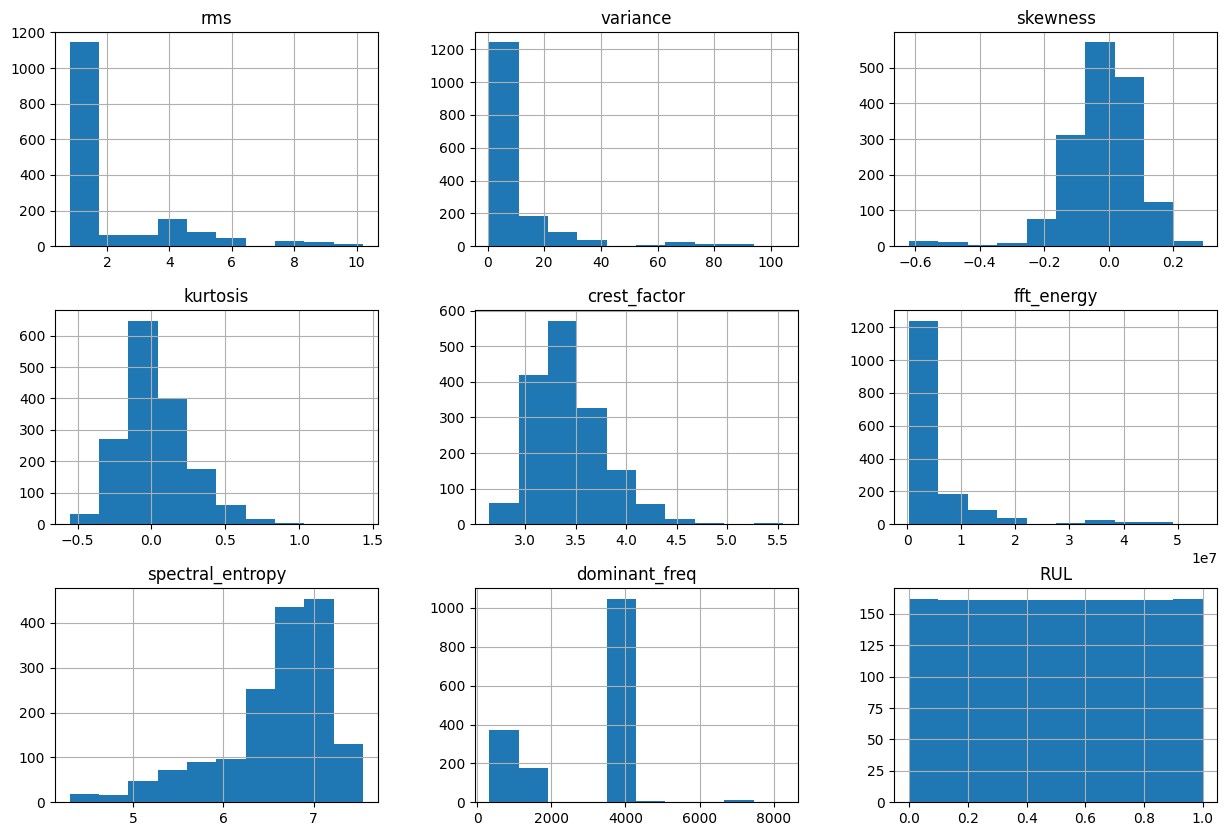

In [52]:
df.hist(figsize=(15,10))

- RMS: The RMS distribution is heavily right-skewed, indicating occasional high vibration spikes associated with bearing degradation.


- Variance: Variance shows extreme dispersion with long tails, suggesting unstable vibration behavior and non-stationary fault progression.


- Skewness: Skewness values are concentrated near zero, indicating that most vibration signals remain approximately symmetric despite degradation events.


- Kurtosis: Kurtosis exhibits a sharp peak with a long positive tail, reflecting impulsive shocks and transient fault impacts in the bearing signals.


- Crest Factor: Crest factor values are concentrated between 3 and 4, with higher outliers indicating sudden impact-related faults or crack initiation.


- FFT Energy: FFT energy is highly right-skewed with several extreme peaks, showing significant increases in vibration energy during degradation stages.


- Spectral Entropy: Spectral entropy is concentrated at higher values, indicating increasing signal complexity and frequency irregularity as faults develop.


- Dominant Frequency: Dominant frequency clusters around specific frequency bands, suggesting recurring fault-related vibration patterns in the machinery.


- RUL: The RUL distribution appears nearly uniform because the Remaining Useful Life values were normalized progressively from healthy to failed states.



### Time_frequency_domain_distribution

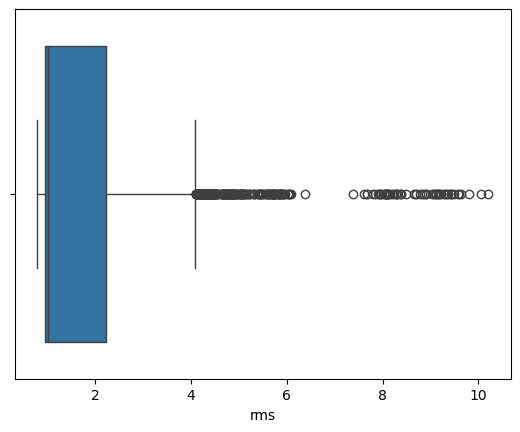

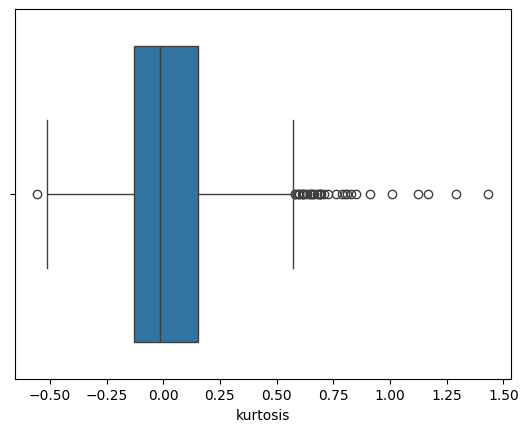

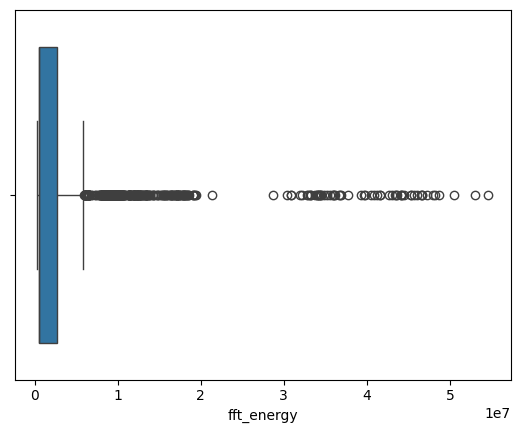

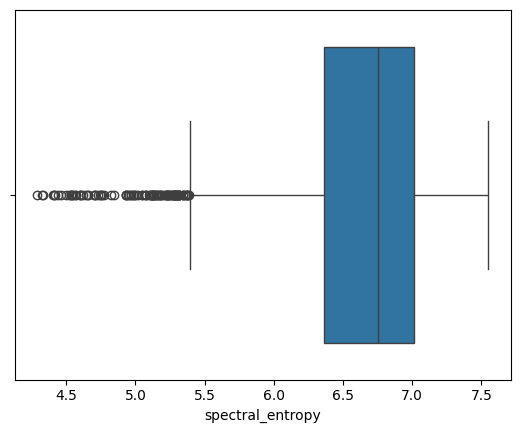

In [53]:
for col in ['rms','kurtosis','fft_energy','spectral_entropy']:
    sns.boxplot(x=df[col])
    plt.show()

- rms is right skewed with number of outliers.
- kurtosis is right skewed.
- fft_energy is extremly right skewed.

### RUL vs rms

<Axes: xlabel='RUL', ylabel='rms'>

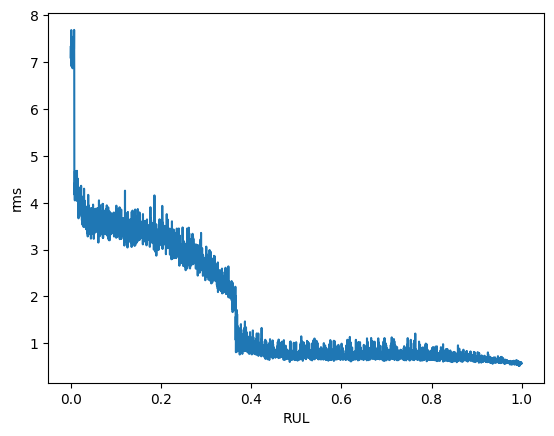

In [54]:
# RUL vs rms for Bearing1_1
bearing = df_xjtu[df_xjtu['bearing_id']=='Bearing1_1']

sns.lineplot(x='RUL', y='rms', data=bearing)

- For the Bearing1_1 as rms decreases the remaining useful life is increasing.

<Axes: xlabel='RUL', ylabel='rms'>

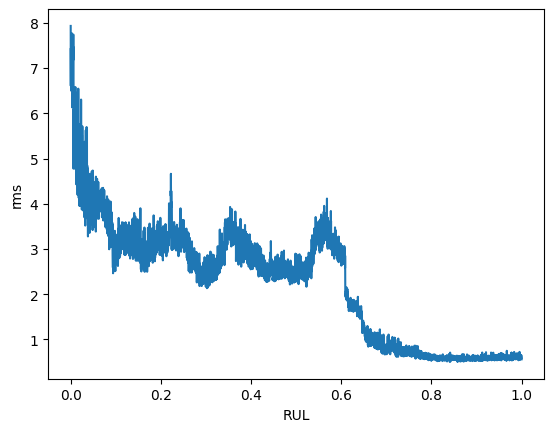

In [55]:
# RUL vs rms for Bearing1_2
bearing = df_xjtu[df_xjtu['bearing_id']=='Bearing1_2']

sns.lineplot(x='RUL', y='rms', data=bearing)

- For the Bearing1_2 as rms is decreasing the remaining useful life is increasing. There are so many sudden spike which makes bearing more prone to degradation.

<Axes: xlabel='RUL', ylabel='rms'>

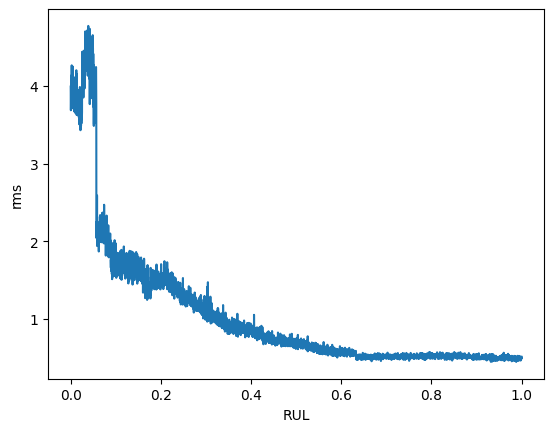

In [56]:
# RUL vs rms for Bearing1_3
bearing = df_xjtu[df_xjtu['bearing_id']=='Bearing1_3']

sns.lineplot(x='RUL', y='rms', data=bearing)

- For the Bearing1_3 as rms is decreasing the remaining useful life is increasing. There is a sudden spike in the beginning and then it seems to have subside.

<Axes: xlabel='RUL', ylabel='rms'>

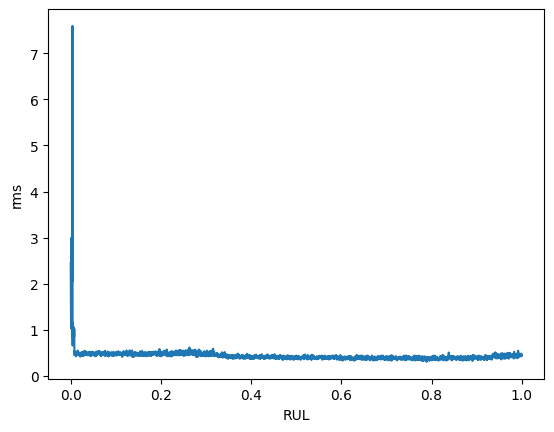

In [57]:
# RUL vs rms for Bearing1_4
bearing = df_xjtu[df_xjtu['bearing_id']=='Bearing1_4']

sns.lineplot(x='RUL', y='rms', data=bearing)

For Bearing1_4, there is a sudden spike and then its almost plain.

<Axes: xlabel='RUL', ylabel='rms'>

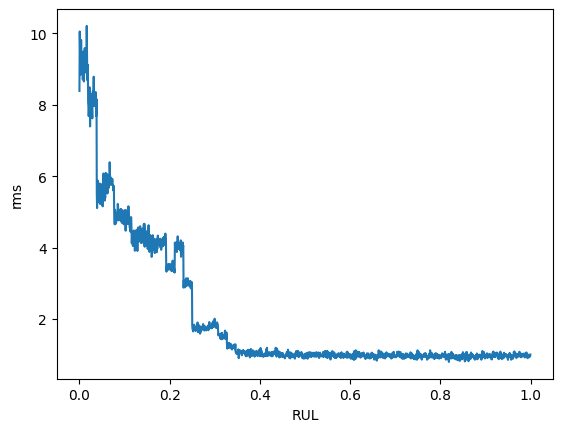

In [58]:
# RUL vs rms for Bearing1_5
bearing = df_xjtu[df_xjtu['bearing_id']=='Bearing1_5']

sns.lineplot(x='RUL', y='rms', data=bearing)

- Bearing1_5 shows a strong inverse relationship between RMS and RUL, where vibration intensity increases sharply as the bearing approaches failure, indicating progressive degradation and instability in later operational stages.

### Correlation

<Axes: >

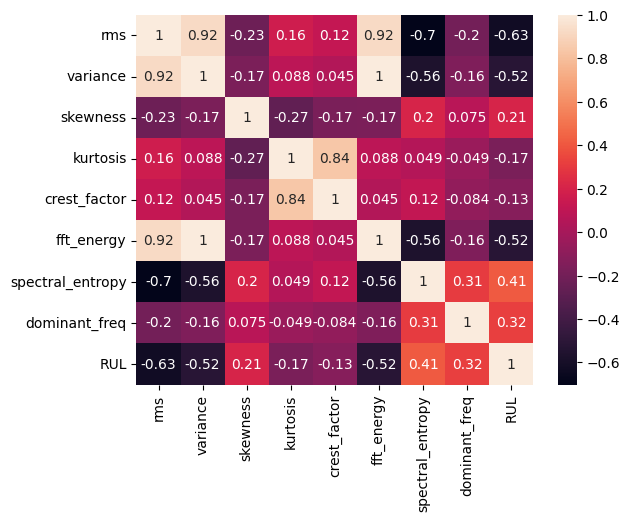

In [59]:
# correlation_map
sns.heatmap(df_xjtu.corr(numeric_only=True), annot=True)

- rms and fft_energy, variance has high correlation.
- crest_factor and kurtosis has high correlation.

In [60]:
df_xjtu.corr(numeric_only=True)['RUL'].sort_values()

,RUL
rms,-0.627172
variance,-0.518247
fft_energy,-0.518245
kurtosis,-0.171590
crest_factor,-0.125871
skewness,0.207000
dominant_freq,0.316503
spectral_entropy,0.412546
RUL,1.000000


<Axes: xlabel='RUL', ylabel='rms'>

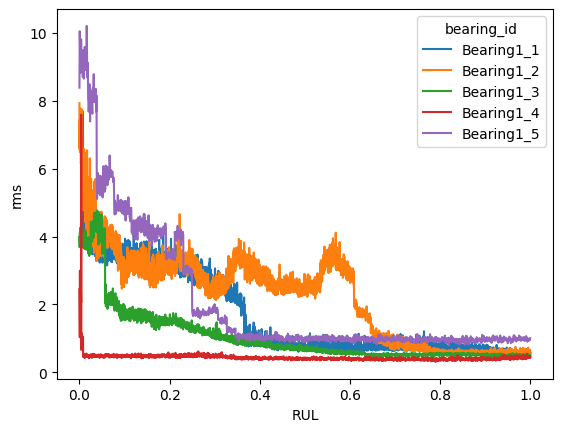

In [61]:
# RUL vs rms
sns.lineplot(data=df_xjtu,x='RUL',y='rms',hue='bearing_id')

# Data Preprocessing

In [62]:
#Creating_labels_for_dataset
def create_labels(df):

    rms_thresh = df['rms'].quantile(0.90)
    kurt_thresh = df['kurtosis'].quantile(0.90)
    fft_thresh = df['fft_energy'].quantile(0.90)

    condition = (
        (df['rms'] > rms_thresh) |
        (df['kurtosis'] > kurt_thresh) |
        (df['fft_energy'] > fft_thresh)
    )

    df['label'] = condition.astype(int)

    return df

In [65]:
rms_cols_ims = [col for col in df_ims.columns if col.startswith('rms_')]
kurtosis_cols_ims = [col for col in df_ims.columns if col.startswith('kurtosis_')]
fft_energy_cols_ims = [col for col in df_ims.columns if col.startswith('fft_energy_')]

df_ims['rms'] = df_ims[rms_cols_ims].mean(axis=1)
df_ims['kurtosis'] = df_ims[kurtosis_cols_ims].mean(axis=1)
df_ims['fft_energy'] = df_ims[fft_energy_cols_ims].mean(axis=1)

df_ims = create_labels(df_ims)

df_xjtu = create_labels(df_xjtu)

df_cross_domain = create_labels(df_cross_domain)

In [66]:
print(df_ims['label'].value_counts())

print(df_xjtu['label'].value_counts())

print(df_cross_domain['label'].value_counts())

label
0    7783
1    1680
Name: count, dtype: int64
label
0    15609
1     3487
Name: count, dtype: int64
label
0    7783
1    1680
Name: count, dtype: int64


# Model_Building

# Research_Questions

- Can a machine learning model trained on one bearing dataset accurately predict faults on another dataset with different operating conditions?

In [69]:
# RQ1 - CROSS DOMAIN GENERALIZATION/ IMS --> XJTU/ COMBINED CLASSICAL ML RESULTS
# Can a machine learning model trained on one bearing dataset accurately predict faults on another dataset with different operating conditions?


from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [70]:
# FEATURES

FEATURES = [
    'rms',
    'variance',
    'skewness',
    'kurtosis',
    'crest_factor',
    'fft_energy',
    'spectral_entropy',
    'dominant_freq'
]

TARGET = 'label'

In [71]:
# TRAIN ON IMS

X_train = df_cross_domain[FEATURES]
y_train = df_cross_domain[TARGET]

# TEST ON XJTU

X_test = df_xjtu[FEATURES]
y_test = df_xjtu[TARGET]

# SCALING

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MODELS

models = {

    "Random Forest": RandomForestClassifier(n_estimators=100,random_state=42),

    "Logistic Regression": LogisticRegression(),

    "SVM": SVC(probability=True)
}

# RESULTS STORAGE

results = []

for name, model in models.items():

    # TRAIN
    model.fit(X_train_scaled, y_train)

    # PREDICT
    preds = model.predict(X_test_scaled)

    # METRICS
    accuracy = accuracy_score(y_test, preds)

    precision = precision_score(y_test, preds)

    recall = recall_score(y_test, preds)

    f1 = f1_score(y_test, preds)

    # STORE RESULTS
    results.append([name,accuracy,precision,recall,f1])


        # PRINT REPORT
    print(f"{name}")

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nClassification Report\n")

    print(classification_report(y_test, preds))


# FINAL RESULTS TABLE

results_df = pd.DataFrame(results,columns=["Model","Accuracy","Precision","Recall","F1 Score"])


print("FINAL RESULTS TABLE")

print(results_df)

Random Forest
Accuracy : 0.1826036866359447
Precision: 0.1826036866359447
Recall   : 1.0
F1 Score : 0.3088163662932294

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     15609
           1       0.18      1.00      0.31      3487

    accuracy                           0.18     19096
   macro avg       0.09      0.50      0.15     19096
weighted avg       0.03      0.18      0.06     19096

Logistic Regression
Accuracy : 0.1826036866359447
Precision: 0.1826036866359447
Recall   : 1.0
F1 Score : 0.3088163662932294

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     15609
           1       0.18      1.00      0.31      3487

    accuracy                           0.18     19096
   macro avg       0.09      0.50      0.15     19096
weighted avg       0.03      0.18      0.06     19096



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

SVM
Accuracy : 0.1826036866359447
Precision: 0.1826036866359447
Recall   : 1.0
F1 Score : 0.3088163662932294

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     15609
           1       0.18      1.00      0.31      3487

    accuracy                           0.18     19096
   macro avg       0.09      0.50      0.15     19096
weighted avg       0.03      0.18      0.06     19096

FINAL RESULTS TABLE
                 Model  Accuracy  Precision   Recall  F1 Score
0        Random Forest  0.182604   0.182604 1.000000  0.308816
1  Logistic Regression  0.182604   0.182604 1.000000  0.308816
2                  SVM  0.182604   0.182604 1.000000  0.308816


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [72]:
# TRAIN ON XJTU

from sklearn.model_selection import train_test_split

X = df_xjtu[FEATURES]
y = df_xjtu[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# SCALING

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MODELS

models = {

    "Random Forest": RandomForestClassifier(n_estimators=100,random_state=42),

    "Logistic Regression": LogisticRegression(),

    "SVM": SVC(probability=True)
}

# RESULTS STORAGE

results = []

for name, model in models.items():

    # TRAIN
    model.fit(X_train_scaled, y_train)

    # PREDICT
    preds = model.predict(X_test_scaled)

    # METRICS
    accuracy = accuracy_score(y_test, preds)

    precision = precision_score(y_test, preds)

    recall = recall_score(y_test, preds)

    f1 = f1_score(y_test, preds)

    # STORE RESULTS
    results.append([name,accuracy,precision,recall,f1])


        # PRINT REPORT
    print(f"{name}")

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nClassification Report\n")

    print(classification_report(y_test, preds))


# FINAL RESULTS TABLE

results_df = pd.DataFrame(results,columns=["Model","Accuracy","Precision","Recall","F1 Score"])


print("FINAL RESULTS TABLE")

print(results_df)

Random Forest
Accuracy : 0.999738219895288
Precision: 1.0
Recall   : 0.998567335243553
F1 Score : 0.9992831541218637

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3122
           1       1.00      1.00      1.00       698

    accuracy                           1.00      3820
   macro avg       1.00      1.00      1.00      3820
weighted avg       1.00      1.00      1.00      3820

Logistic Regression
Accuracy : 0.9591623036649215
Precision: 0.9195046439628483
Recall   : 0.8510028653295129
F1 Score : 0.8839285714285714

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      3122
           1       0.92      0.85      0.88       698

    accuracy                           0.96      3820
   macro avg       0.94      0.92      0.93      3820
weighted avg       0.96      0.96      0.96      3820

SVM
Accuracy : 0.9895287958115183
Precisi

- Which statistical vibration features contribute most to accurate bearing fault prediction across multiple datasets?

            Feature  Importance
3          kurtosis    0.323481
5        fft_energy    0.304600
0               rms    0.134614
1          variance    0.106113
6  spectral_entropy    0.049545
4      crest_factor    0.048133
7     dominant_freq    0.018995
2          skewness    0.014519


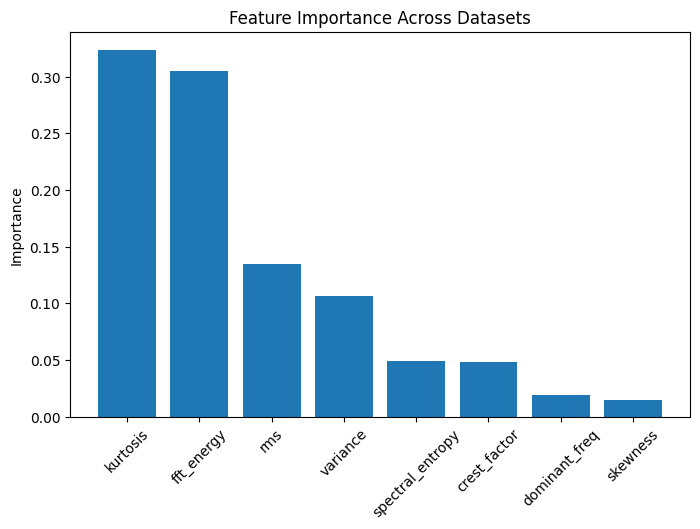

In [73]:
# Which statistical vibration features contribute most to accurate bearing fault prediction across multiple datasets?


combined_df = pd.concat([df_ims,df_xjtu,df_cross_domain])


FEATURES = ['rms','variance','skewness','kurtosis','crest_factor','fft_energy','spectral_entropy','dominant_freq']

X = combined_df[FEATURES]
y = combined_df['label']


rf = RandomForestClassifier(n_estimators=200,random_state=42)

rf.fit(X, y)

importance_df = pd.DataFrame({'Feature': FEATURES,'Importance': rf.feature_importances_})

importance_df = importance_df.sort_values(by='Importance',ascending=False)

print(importance_df)




plt.figure(figsize=(8,5))

plt.bar(importance_df['Feature'],importance_df['Importance'])

plt.xticks(rotation=45)

plt.title("Feature Importance Across Datasets")

plt.ylabel("Importance")

plt.show()

- Do frequency-domain features detect faults earlier than time-domain features?

In [74]:
# Do frequency-domain features detect faults earlier than time-domain features?

time_features = ['rms','variance','skewness','kurtosis','crest_factor']

In [75]:
freq_features = ['fft_energy','spectral_entropy','dominant_freq']

In [78]:
y = df_cross_domain['label']

# TIME DOMAIN
X_time = df_cross_domain[time_features]

X_train_t, X_test_t, y_train, y_test = train_test_split(X_time,y,test_size=0.2,random_state=42,stratify=y)

scaler = StandardScaler()

X_train_t = scaler.fit_transform(X_train_t)
X_test_t = scaler.transform(X_test_t)

model_time = RandomForestClassifier(n_estimators=100,random_state=42)

model_time.fit(X_train_t, y_train)

preds_time = model_time.predict(X_test_t)

time_acc = accuracy_score(y_test, preds_time)
time_f1 = f1_score(y_test, preds_time)

# FREQUENCY DOMAIN

X_freq = df_cross_domain[freq_features]

X_train_f, X_test_f, y_train, y_test = train_test_split(X_freq,y,test_size=0.2,random_state=42,stratify=y)

X_train_f = scaler.fit_transform(X_train_f)
X_test_f = scaler.transform(X_test_f)

model_freq = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_freq.fit(X_train_f, y_train)

preds_freq = model_freq.predict(X_test_f)

freq_acc = accuracy_score(y_test, preds_freq)
freq_f1 = f1_score(y_test, preds_freq)

# RESULTS


rq3_results = pd.DataFrame({

    'Feature Type': ['Time Domain', 'Frequency Domain'],
    'Accuracy': [time_acc, freq_acc],
    'F1 Score': [time_f1, freq_f1]

})

print(rq3_results)

       Feature Type  Accuracy  F1 Score
0       Time Domain  0.998415  0.995516
1  Frequency Domain  0.932911  0.795491


- Statistical time-domain features were more discriminative than frequency-domain features for this specific dataset and labeling strategy.

- Do machine learning models outperform traditional threshold-based methods for fault detection in IMS data?

In [79]:
# Do machine learning models outperform traditional threshold-based methods for fault detection in IMS data?


threshold = (df_ims['rms'].mean() + 2 * df_ims['rms'].std())

threshold_preds = (df_ims['rms'] > threshold).astype(int)

threshold_acc = accuracy_score(df_ims['label'],threshold_preds)

threshold_f1 = f1_score(df_ims['label'],threshold_preds)

print("Threshold Accuracy:", threshold_acc)
print("Threshold F1:", threshold_f1)

Threshold Accuracy: 0.8333509457888619
Threshold F1: 0.1155356141334829


In [80]:
rq4_results = pd.DataFrame({

    'Method': [
        'Threshold','Random Forest','Logistic Regression','SVM'],

    'F1 Score': [threshold_f1,0.999283,0.883929,0.971098]
})

print(rq4_results)

                Method  F1 Score
0            Threshold  0.115536
1        Random Forest  0.999283
2  Logistic Regression  0.883929
3                  SVM  0.971098


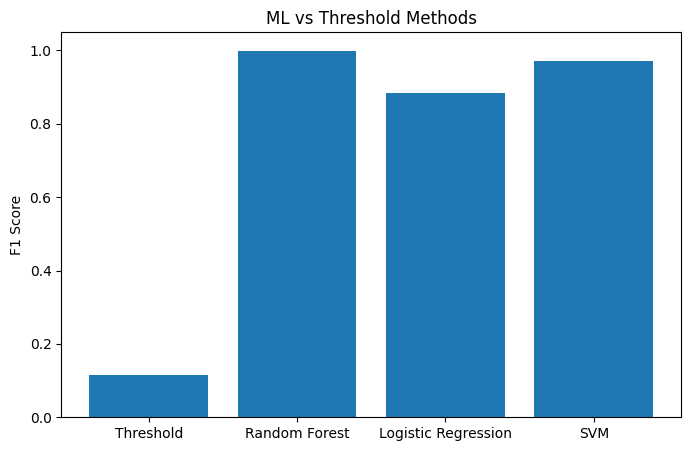

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    rq4_results['Method'],
    rq4_results['F1 Score']
)

plt.title("ML vs Threshold Methods")

plt.ylabel("F1 Score")

plt.show()

- The results demonstrate that machine learning models significantly outperform traditional statistical threshold-based methods for bearing fault detection. While threshold methods rely on fixed statistical limits and are sensitive to noise and operational variability, machine learning models are capable of learning complex nonlinear degradation patterns from vibration features, resulting in substantially higher classification performance.
